In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load dataset (AirPassengers)
df = pd.read_csv("AirPassengers.csv")

# Convert to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set index
df.set_index('Month', inplace=True)

# Rename column for clarity
df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


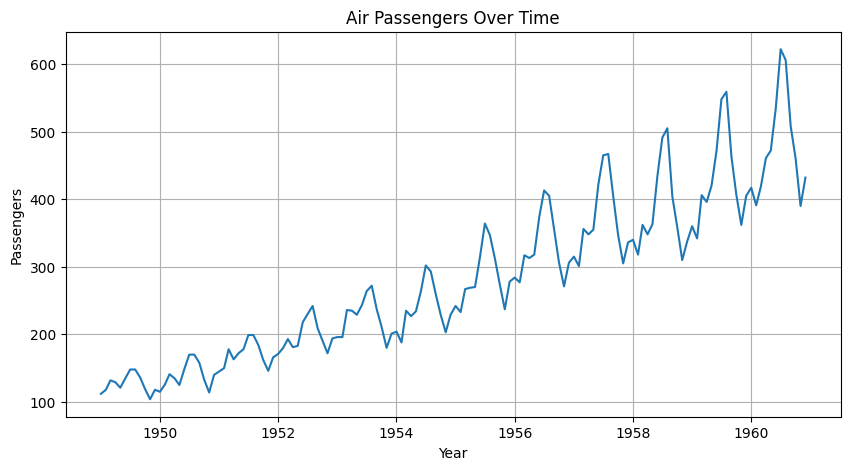

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Passengers'])
plt.title("Air Passengers Over Time")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid()
plt.show()

In [7]:
result = adfuller(df['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


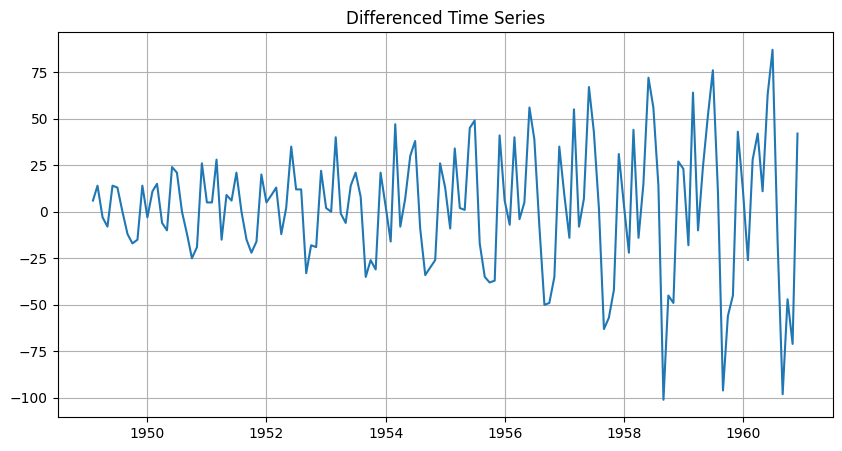

In [8]:
df_diff = df.diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(df_diff)
plt.title("Differenced Time Series")
plt.grid()
plt.show()

In [9]:
model_ar = AutoReg(df_diff, lags=5)
model_ar_fit = model_ar.fit()

print("AR Model AIC:", model_ar_fit.aic)
print("AR Model BIC:", model_ar_fit.bic)

AR Model AIC: 1346.1833358709741
AR Model BIC: 1366.6741116670746


In [10]:
model_ma = ARIMA(df_diff, order=(0,0,5))
model_ma_fit = model_ma.fit()

print("MA Model AIC:", model_ma_fit.aic)
print("MA Model BIC:", model_ma_fit.bic)

MA Model AIC: 1410.544336328444
MA Model BIC: 1431.2842487402634


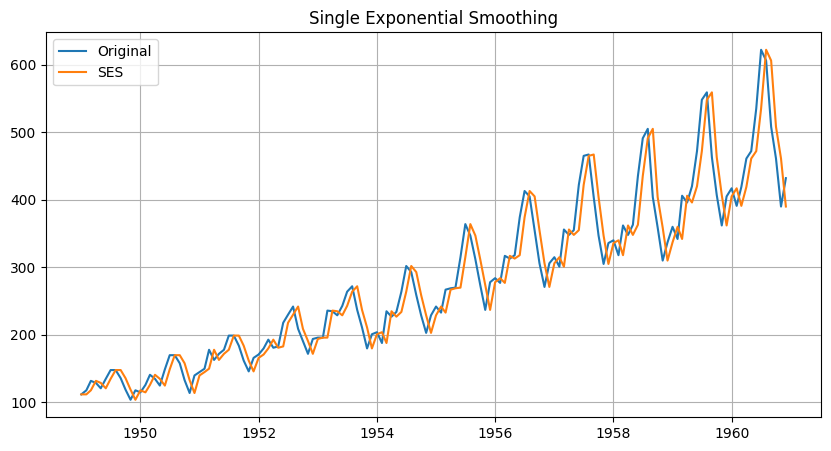

In [11]:
model_ses = SimpleExpSmoothing(df['Passengers']).fit()

df['SES'] = model_ses.fittedvalues

plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label='Original')
plt.plot(df['SES'], label='SES')
plt.legend()
plt.title("Single Exponential Smoothing")
plt.grid()
plt.show()

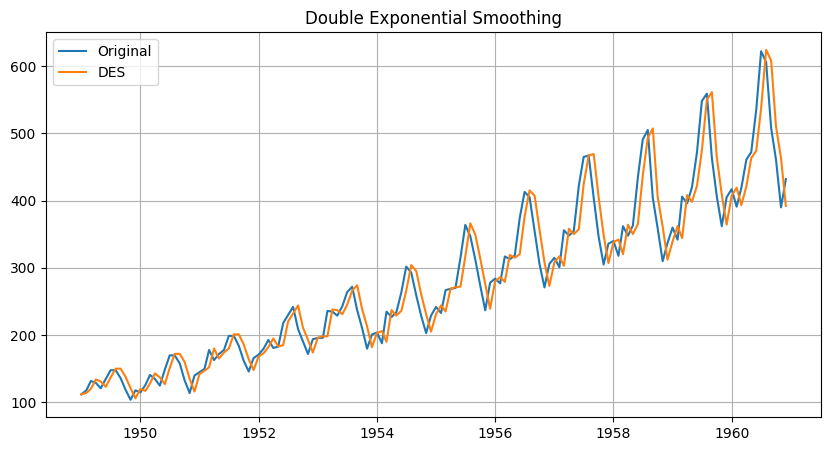

In [12]:
model_des = ExponentialSmoothing(df['Passengers'], trend='add').fit()

df['DES'] = model_des.fittedvalues

plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label='Original')
plt.plot(df['DES'], label='DES')
plt.legend()
plt.title("Double Exponential Smoothing")
plt.grid()
plt.show()

In [13]:
model_arma = ARIMA(df_diff, order=(2,0,2))
model_arma_fit = model_arma.fit()

print("ARMA Model AIC:", model_arma_fit.aic)
print("ARMA Model BIC:", model_arma_fit.bic)

ARMA Model AIC: 1344.0436825264878
ARMA Model BIC: 1361.8207503080473


In [14]:
model_arima = ARIMA(df['Passengers'], order=(2,1,2))
model_arima_fit = model_arima.fit()

print("ARIMA Model AIC:", model_arima_fit.aic)
print("ARIMA Model BIC:", model_arima_fit.bic)

ARIMA Model AIC: 1353.3466405456597
ARIMA Model BIC: 1368.1608636969593


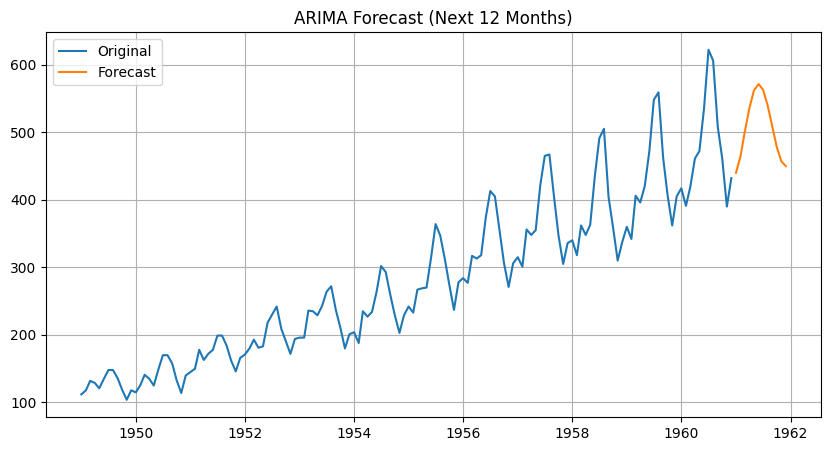

In [15]:
forecast = model_arima_fit.forecast(steps=12)

plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label='Original')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast (Next 12 Months)")
plt.grid()
plt.show()

In [16]:
comparison = pd.DataFrame({
    "Model": ["AR", "MA", "ARMA", "ARIMA"],
    "AIC": [
        model_ar_fit.aic,
        model_ma_fit.aic,
        model_arma_fit.aic,
        model_arima_fit.aic
    ],
    "BIC": [
        model_ar_fit.bic,
        model_ma_fit.bic,
        model_arma_fit.bic,
        model_arima_fit.bic
    ]
})

comparison.sort_values(by="AIC")

,Model,AIC,BIC
2,ARMA,1344.043683,1361.820750
0,AR,1346.183336,1366.674112
3,ARIMA,1353.346641,1368.160864
1,MA,1410.544336,1431.284249


- The dataset shows an increasing trend and seasonality.
- Differencing was applied to make data stationary.
- ARIMA model performed best based on lowest AIC and BIC.
- SES failed to capture trend, DES improved results.
- AR and MA models worked moderately well.